In [4]:
import pandas as pd
import numpy as np

# 探索数据特征

## 读取数据

In [5]:
inputfile = './data/original_data.xlsx'  # 输入的数据文件路径
outputfile='./data/dividsequence.xlsx'   # 输出数据的路径



## 数据质量分析

### 查看缺失值

In [6]:
# ============================================================
# 缺失值检测
# 目的：检查数据集中哪些列有缺失值（空值/NaN）
# 方法：isnull() 判断每个单元格是否为空 → sum() 按列求和，统计空值数量
# ============================================================
data = pd.read_excel(inputfile)  # 先读取原始数据
print('各列缺失值数量：')
data.isnull().sum()  # 输出每列的缺失值个数，全为0说明数据完整

各列缺失值数量：


热水器编号     0
发生时间      0
开关机状态     0
加热中       0
保温中       0
有无水流      0
实际温度      0
热水量       0
水流量       0
节能模式      0
加热剩余时间    0
当前设置温度    0
dtype: int64

结果表明：数据集各列数据均无缺失值

### 查看异常值

In [7]:
# ============================================================
# 异常值检测（通过查看唯一值来发现恒定列）
# 目的：找出每个列有多少个不同的取值
# 如果某列只有 1 个唯一值 → 所有行都一样 → 对建模/分析无贡献 → 应删除
# ============================================================
print('各列唯一值数量：')
data.nunique()  # nunique() 统计每列有多少个不同的值

各列唯一值数量：


热水器编号         1
发生时间      18822
开关机状态         2
加热中           2
保温中           2
有无水流          2
实际温度         24
热水量           4
水流量          53
节能模式          1
加热剩余时间       31
当前设置温度        1
dtype: int64

热水器编号 = R_00001 → 只有这一个值，因为这是同一台热水器  
节能模式 = 关 → 可能这个用户从来不开节能模式  
当前设置温度 = 50°C → 这个用户一直设定在50°C，没改过  
这些信息告诉我们：有些列只有一个值，对建模没用，后面要删掉。  

In [8]:
# ============================================================
# 1. 逻辑一致性检查
# 水流量 > 10 但 "有无水流" = "无" → 异常（有水流量说明肯定有水流）
# 如果存在这种记录，说明数据采集有误或传感器故障
# ============================================================
abnormal_flow = data[(data['水流量'] > 10) & (data['有无水流'] == '无')]
print(f'水流量>10但标记为"无水流"的异常记录数：{len(abnormal_flow)}')
abnormal_flow  # 查看具体的异常记录

水流量>10但标记为"无水流"的异常记录数：153


,热水器编号,发生时间,开关机状态,加热中,保温中,有无水流,实际温度,热水量,水流量,节能模式,加热剩余时间,当前设置温度
381,R_00001,20211019094638,关,关,关,无,29°C,0%,16,关,0分钟,50°C
382,R_00001,20211019094640,关,关,关,无,29°C,0%,13,关,0分钟,50°C
451,R_00001,20211019153741,关,关,关,无,29°C,0%,11,关,0分钟,50°C
1353,R_00001,20211020072622,关,关,关,无,35°C,0%,17,关,0分钟,50°C
1444,R_00001,20211020133354,关,关,关,无,31°C,0%,12,关,0分钟,50°C
...,...,...,...,...,...,...,...,...,...,...,...,...
18141,R_00001,20211110160113,开,开,关,无,31°C,25%,12,关,26分钟,50°C
18405,R_00001,20211110185219,开,关,开,无,49°C,50%,16,关,0分钟,50°C
18450,R_00001,20211110185950,开,关,开,无,47°C,100%,11,关,0分钟,50°C
18535,R_00001,20211110213831,开,关,开,无,50°C,100%,12,关,0分钟,50°C


In [9]:
# ============================================================
# 2. 值域检查
# 实际温度不可能 > 100°C 或 < 0°C（物理上不可能）
# 注意：温度列带有 "°C" 后缀，需要先去掉再转换为数值
# ============================================================
temp_str = data['实际温度'].astype(str).str.replace('°C', '')  # 去掉 °C 符号
temp_num = pd.to_numeric(temp_str, errors='coerce')             # 转为数值（无法转换的变为 NaN）
abnormal_temp = data[(temp_num > 100) | (temp_num < 0)]          # 找出温度异常的记录
print(f'温度异常的记录数：{len(abnormal_temp)}')
abnormal_temp

温度异常的记录数：0


,热水器编号,发生时间,开关机状态,加热中,保温中,有无水流,实际温度,热水量,水流量,节能模式,加热剩余时间,当前设置温度


### 查看重复值

In [10]:
# ============================================================
# 重复值检测
# 目的：检查数据集中是否有完全相同的记录（所有列的值都一样）
# duplicated() 返回布尔序列，True 表示该行与前面的某行完全重复
# ============================================================
print(f'完全重复的记录数：{data.duplicated().sum()}')
# 如果有重复，可以用 data[data.duplicated()] 查看具体是哪几行

完全重复的记录数：0


结果表明：数据集各列数据均无重复值

## 水流量分布分析

### 查看有无水流的分析

“有无水流”和“水流量”属性最能直观体现热水器的水流情况，对这两个属性进行探索，可以通过频率分布直方图分析用户用水时间间隔的规律性

In [11]:
# ============================================================
# 查看有无水流的分布
# 目的：统计"有无水流"这一列里，"有"和"无"各有多少条记录
# 这是最基础的水流情况分析 —— 用户大部分时间在用水还是不用水？
# ============================================================
lv_non = (data['有无水流'] == '无').sum()   # 无水流的总记录数
lv_move = (data['有无水流'] == '有').sum()  # 有水流的总记录数
print(f'无水流记录数：{lv_non}')
print(f'有水流记录数：{lv_move}')
print(f'有水占比：{lv_move / (lv_non + lv_move) * 100:.1f}%')

无水流记录数：11422
有水流记录数：7418
有水占比：39.4%


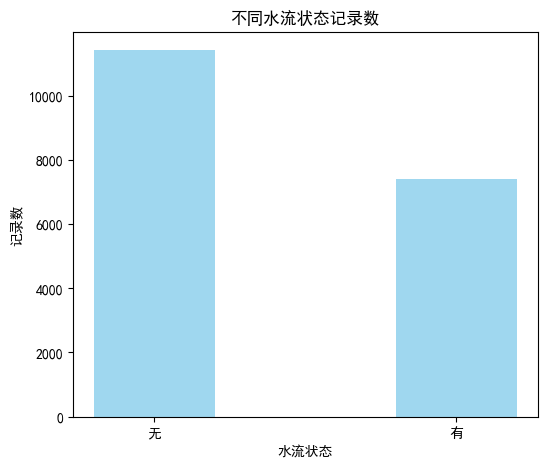

In [12]:
#探索分析热水器的水流量状况
import matplotlib.pyplot as plt

# 绘制条形图
fig = plt.figure(figsize=(6 ,5))  # 设置画布大小，宽6英寸、高5英寸
plt.rcParams['font.sans-serif'] = 'SimHei'  # 设置中文显示
plt.rcParams['axes.unicode_minus'] = False
plt.bar(x=range(2), height=[lv_non,lv_move], width=0.4, alpha=0.8,color='skyblue')  # 画条形图，横坐标0和1，高度分别是“无”和“有”的个数
plt.xticks([index for index in range(2)], ['无','有'])  # 设置横坐标标签为“无”和“有”
plt.xlabel('水流状态')  # 设置横轴标题
plt.ylabel('记录数')  # 设置纵轴标题
plt.title('不同水流状态记录数')  # 设置图表标题
plt.show()  # 显示图表
plt.close()  # 关闭图表，释放内存

告诉我们：有多少条记录是有水的，多少条是无水的  
可以看出：无水流记录比有水流多

### 查看水流量的分布

In [13]:
# ============================================================
# 查看水流量分布
# 目的：取出"水流量"这一列数据，了解水流量的整体情况
# 水流量是判断用户是否在用水以及用水强度的关键指标
# ============================================================
water = data['水流量']  # 取出水流量列（Series）
print(f'水流量统计：')
print(f'  均值 = {water.mean():.2f}')
print(f'  最大值 = {water.max()}')
print(f'  非零记录数 = {(water > 0).sum()}')
print(f'  零值记录数 = {(water == 0).sum()}')

水流量统计：
  均值 = 12.87
  最大值 = 77
  非零记录数 = 7696
  零值记录数 = 11144


C:\Users\win11\AppData\Local\Temp\ipykernel_8904\3231261254.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(water,


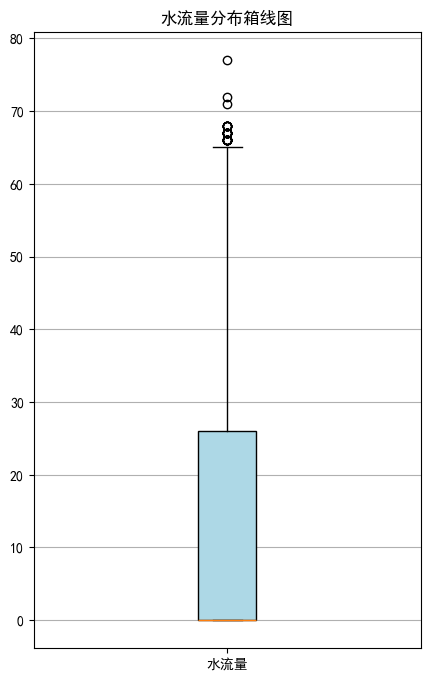

In [14]:
# 绘制水流量分布箱型图
fig = plt.figure(figsize=(5 ,8))
plt.boxplot(water,
            patch_artist=True,  # 给箱子填充颜色
            labels = ['水流量'],  # 设置x轴标题
            boxprops = {'facecolor':'lightblue'})  # 设置填充颜色
plt.title('水流量分布箱线图')
# 显示y坐标轴的底线
plt.grid(axis='y')  # 添加水平网格线，方便看数值
plt.show()

告诉我们：水流量的具体数值分布  
可以看出：箱体贴近0 → 大量数据是0（无水流）

# 数据预处理

## 数据变换之连续属性离散化

### 用水停顿时间的分布情况

用水停顿事件间隔 = 一条水流量不为0的记录时间 至 下一条水流量不为0的记录时间

时间线（只看有水的时刻）：  

记录A：07:01:56（水流量=8）  ← 正在用水  
        ↓   
        （间隔了一段时间）  
记录B：07:38:16（水流量=8）  ← 又在用水  

记录B的时间(07:38:16) - 记录A的时间(07:01:56) = 36分20秒  
这个36分20秒就是两次用水之间的停顿时长。

这个指标有什么用？  

| 间隔长短 | 含义 |
| :--- | :--- |
| 很短（几秒） | 可能是同一次用水（比如洗澡中间搓澡） |
| 中等（几分钟） | 可能是不同事情（洗手→洗碗） |
| 很长（十几分钟） | 肯定是不同次用水 |

切分用水事件的核心：间隔 < 4分钟 → 算同一次用水；间隔 > 4分钟 → 算新的一次用水。

In [15]:
# ============================================================
# 将"发生时间"列转换为 datetime 格式
# 原始格式示例：20211019063917 → 2021年10月19日06时39分17秒
# format='%Y%m%d%H%M%S' 告诉 pandas 如何解析这个字符串
# 只有转成 datetime 后才能做时间差计算（如 diff()）
# ============================================================
data['发生时间'] = pd.to_datetime(data['发生时间'], format='%Y%m%d%H%M%S')
print(f'转换后时间列类型：{data["发生时间"].dtype}')
data['发生时间'].head(3)  # 查看前3条，确认转换正确

转换后时间列类型：datetime64[us]


0   2021-10-19 06:39:17
1   2021-10-19 07:01:54
2   2021-10-19 07:01:56
Name: 发生时间, dtype: datetime64[us]

In [16]:
# ============================================================
# 提取水流量不为 0 的记录
# 目的：只保留"真正在用水"的行（水流量 > 0 才说明水龙头开着）
# 水流量 = 0 的记录是用水之间的停顿或未使用状态
# .copy() 避免后续操作触发 SettingWithCopyWarning
# ============================================================
use_water = data[data['水流量'] > 0].copy()
print(f'总记录数：{len(data)}，有水记录数：{len(use_water)}，占比：{len(use_water)/len(data)*100:.1f}%')
use_water.head()  # 查看前几条有水记录

总记录数：18840，有水记录数：7696，占比：40.8%


,热水器编号,发生时间,开关机状态,加热中,保温中,有无水流,实际温度,热水量,水流量,节能模式,加热剩余时间,当前设置温度
2,R_00001,2021-10-19 07:01:56,关,关,关,无,30°C,0%,8,关,0分钟,50°C
56,R_00001,2021-10-19 07:38:16,关,关,关,无,30°C,0%,8,关,0分钟,50°C
381,R_00001,2021-10-19 09:46:38,关,关,关,无,29°C,0%,16,关,0分钟,50°C
382,R_00001,2021-10-19 09:46:40,关,关,关,无,29°C,0%,13,关,0分钟,50°C
384,R_00001,2021-10-19 09:47:15,关,关,关,有,29°C,0%,20,关,0分钟,50°C


In [17]:
# diff()：计算相邻两条时间之间的差值（比如 10:00:03 - 10:00:01 = 2秒）
# [1:]：去掉第一个（因为第一条没有前一条可以减）
# / np.timedelta64(1, 'm')：把时间差值转换成分钟
use_diff = use_water['发生时间'].diff()[1:] / np.timedelta64(1, 'm')         
use_diff

56        36.333333
381      128.366667
382        0.033333
384        0.583333
404      123.033333
            ...    
18742      0.033333
18743      0.066667
18744      0.066667
18798     18.950000
18800     29.400000
Name: 发生时间, Length: 7695, dtype: float64

use_diff 存储的就是：每次用水结束到下一次用水开始之间的停顿时间。

In [18]:
# ============================================================
# 定义分箱边界和标签
# space：区间分界点（分钟），把连续的停顿时间切到离散区间
# labels：每个区间对应的标签名，共 len(space)-1 = 14 个区间
# ============================================================
space = [0, 0.1, 0.2, 0.3, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 13, 800]
labels = ['0~0.1', '0.1~0.2', '0.2~0.3', '0.3~0.5', '0.5~1',
          '1~2', '2~3', '3~4', '4~5', '5~6', '6~7', '7~8', '8~13', '13以上']

In [19]:
# ============================================================
# 分箱（连续值 → 离散区间）
# 目的：将连续的停顿时间划分到不同的区间，统计每个区间的频数
# pd.cut()：把连续数值切成离散的"箱子"
#   bins=space：用之前定义的分界点来切
#   labels=labels：每个箱子对应的标签名
#   right=False：区间左闭右开 [a, b)，如 [0, 0.1)
# value_counts()：统计每个箱子里有多少条记录
# sort_index()：按索引（即区间顺序）排序，保证从短到长
# ============================================================
time_table = pd.cut(use_diff, bins=space, labels=labels, right=False).value_counts().sort_index()
print('各区间停顿次数统计：')
time_table

各区间停顿次数统计：


发生时间
0~0.1      5576
0.1~0.2    1385
0.2~0.3     324
0.3~0.5     119
0.5~1        46
1~2          33
2~3          15
3~4          14
4~5           1
5~6           8
6~7           5
7~8           6
8~13         18
13以上        125
Name: count, dtype: int64

核心发现：  
短停顿（<1分钟）：5576 + 1385 + 324 + 119 + 46 = 7450次  
长停顿（>13分钟）：134次  

关键结论：  
绝大多数停顿都很短（<1分钟）  
这些短停顿 → 属于同一次用水中间的自然停顿（洗澡搓澡、打沐浴露）  
长停顿 → 才是真正的两次不同用水之间的间隔

从结果看：  
3-4分钟：只有14次停顿   
4-5分钟：只有1次停顿  
这说明：超过3分钟的停顿已经很少了，用4分钟作为"切分点"是合理的。

### 绘制用水停顿时间帕累托图

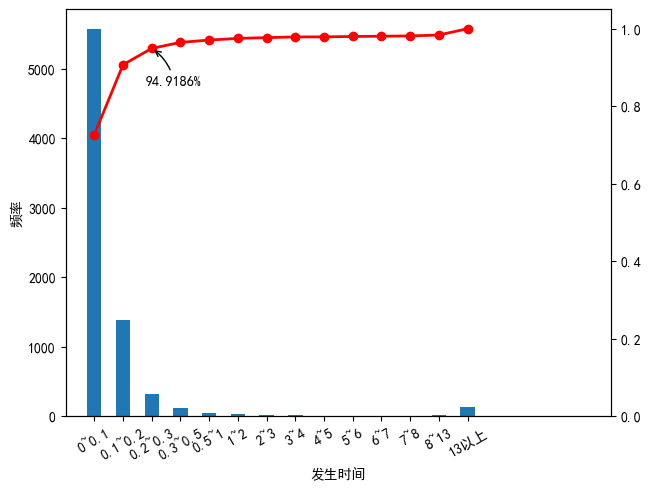

In [20]:
plt.rcParams['figure.constrained_layout.use'] = True    # 自动调整图表布局，避免标签被遮挡
plt.rcParams['font.sans-serif'] = ['SimHei']    # 显示中文
ax = time_table.plot(kind='bar')  # 画柱状图，横坐标是区间，纵坐标是频数
ax.set_xlabel('区间')  # 横轴标题
ax.set_ylabel('频率')  # 纵轴标题
p = 1.0 * time_table.cumsum() / time_table.sum()
# time_table.cumsum()：计算累计频数（第一个区间+第二个区间+...）
# time_table.sum()：计算总频数
# p = ...：计算累计百分比（累计频数 ÷ 总频数）
ax2 = p.plot(color='r', secondary_y=True, style='-o', linewidth=2, rot=30)  
# 画累计百分比曲线
# color='r'：线条颜色为红色
# secondary_y=True：使用右侧的纵坐标轴（和柱状图的左侧轴分开）
# style='-o'：线条样式：实线+圆点
# linewidth=2：线条粗细为2
# rot=30：横坐标标签旋转30度
ax2.set_ylim((0, 1.05))  # 右侧Y轴范围：0% 到 105%
ax2.set_xlim(-1, 18)  # X轴范围：-1 到 18（留一点边距）
plt.annotate(format(p.iloc[2], '0.4%'), xy=(2, p.iloc[2]), xytext=(2*0.9, p.iloc[2]*0.9), 
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3, rad=.2'))    # 绘制文本与箭头
# plt.annotate(...)：在图上添加注释（文字+箭头）
# format(p[2], '0.4%')：把第3个区间的累计百分比格式化成百分比（如"85.00%"）
# xy=(2, p[2])：箭头指向的位置（第3个柱子的顶部）
# xytext=(2*0.9, p[2]*0.9)：文字放置的位置（向左下方偏移一点）
# arrowprops=...：箭头的样式
plt.show()
plt.close()

0-0.1分钟：5576次 → 占 72.5%  
0-0.2分钟：6961次 → 占 90.5%  
0-0.3分钟：7285次 → 占 94.8%  ← 这里  
含义：94.8%的停顿都在0.3分钟（18秒）以内

结论：用户的大部分停顿都极短（<18秒），4分钟的阈值足够安全，不会把一次洗澡切碎，也不会把两次洗澡合并。

## 数据规约之属性规约

In [21]:
# 读取数据
data = pd.read_excel(inputfile) 
print('初始状态的数据形状为：', data.shape)

初始状态的数据形状为： (18840, 12)


In [22]:
# ============================================================
# 删除冗余属性（属性规约）
# 目的：删除对建模无贡献的列，降低数据维度
# 根据前面的 nunique() 分析：
#   热水器编号 = 只有 R_00001（同一台机器）
#   节能模式 = 只有"关"（用户从不开启）
#   当前设置温度 = 只有 50°C（用户从不调整）
# 这些列所有行的值都一样，无法帮助区分不同的用水事件，所以要删除
# ============================================================
data.drop(['热水器编号', '节能模式', '当前设置温度'], axis=1, inplace=True)
print('删除冗余属性后的数据形状为：', data.shape)
print('剩余列名：', list(data.columns))

删除冗余属性后的数据形状为： (18840, 9)
剩余列名： ['发生时间', '开关机状态', '加热中', '保温中', '有无水流', '实际温度', '热水量', '水流量', '加热剩余时间']


## 数据集成之合并数据

### 划分单次用水事件

把连续的数据流，切分成一个个独立的"用水事件"。

1）第一步：设定“切分”的标准

前面得到的结论：如果两次用水记录之间的间隔超过4分钟，就认为这是两次不同的用水事件（比如一次洗手和一次洗澡）。如果间隔小于4分钟，就认为它们属于同一次用水（比如洗澡中间搓沐浴露的停顿）。

In [23]:
import pandas as pd
threshold=pd.Timedelta(minutes=4)#阈值为4分钟
threshold

Timedelta('0 days 00:04:00')

2）第二步：准备数据，只保留“有水”的记录

In [24]:
# ============================================================
# 读取和准备数据（划分事件前的数据准备）
# 第1步：读取原始数据，转换时间格式
# 第2步：只保留水流量 > 0 的记录（无水的记录对划分事件没有帮助）
# ============================================================
inputfile = './data/original_data.xlsx'                            # 输入的数据文件路径
data = pd.read_excel(inputfile)                                    # 读取原始数据
data["发生时间"] = pd.to_datetime(data["发生时间"], format="%Y%m%d%H%M%S")  # 转换时间格式
data = data[data['水流量'] > 0].copy()                              # 只要水流量大于0的记录
print(f'有水记录数：{len(data)}')
data.head()

有水记录数：7696


,热水器编号,发生时间,开关机状态,加热中,保温中,有无水流,实际温度,热水量,水流量,节能模式,加热剩余时间,当前设置温度
2,R_00001,2021-10-19 07:01:56,关,关,关,无,30°C,0%,8,关,0分钟,50°C
56,R_00001,2021-10-19 07:38:16,关,关,关,无,30°C,0%,8,关,0分钟,50°C
381,R_00001,2021-10-19 09:46:38,关,关,关,无,29°C,0%,16,关,0分钟,50°C
382,R_00001,2021-10-19 09:46:40,关,关,关,无,29°C,0%,13,关,0分钟,50°C
384,R_00001,2021-10-19 09:47:15,关,关,关,有,29°C,0%,20,关,0分钟,50°C


第381、382、384行之间时间很近（几秒到几十秒），很可能属于同一次用水（比如一次洗澡）。  
第56行和第381行之间隔了2个多小时，明显是不同次用水。    
所以我们要做的是：把时间上靠近的记录合并成一“事件”，时间上远离的切开。

3）第三步：找出“需要切开”的地方

d 的作用：标记"这里是一个新事件的开始"

In [25]:
threshold = pd.Timedelta(minutes=4)  # 阈值为4分钟
d=data['发生时间'].diff()>threshold 
# 作用：计算每一条记录和上一条记录的时间差，判断是否大于4分钟。
# 结果：得到一列 True/False。
# True → 该记录和上一条间隔 > 4分钟，应该从这里切一刀，作为新事件的开始。
# False → 间隔很短，继续归为同一次事件。

In [26]:
# ============================================================
# 第一条记录没有"上一条"可以比较，所以 diff() 会产生 NaN
# NaN > threshold 的结果是 False，这不对——第一条应该是新事件的开始
# 所以手动把 d 的第一个值设为 True，表示它是第一个用水事件的开始
# ============================================================
d.iloc[0] = True  # 强制第一条为 True（第一个事件的开始）
d.head(10)        # 查看前10条，验证设置成功

2       True
56      True
381     True
382    False
384    False
404     True
407     True
410     True
411    False
412    False
Name: 发生时间, dtype: bool

| Python索引 | 发生时间 | 与上一条的时间差 | 是否>4分钟？ | d |
|------|----------|----------------|-------------|-----|
| 2    | 07:01:56 | —（没有上一条） | —           | True（强制设为开始） |
| 56   | 07:38:16 | 36分20秒       | ✅ 是       | True |
| 381  | 09:46:38 | 2小时8分22秒   | ✅ 是       | True |
| 382  | 09:46:40 | 2秒            | ❌ 否       | False |
| 384  | 09:47:15 | 35秒           | ❌ 否       | False |
| 404  | 11:50:17 | 2小时3分2秒    | ✅ 是       | True |

d 列的含义：  
True = 这里是一个新事件的开头  
False = 跟上一条属于同一个事件

从 d 列可以看出：  
事件1：从行2开始  
事件2：从行56开始  
事件3：从行381开始（包括381、382、384）  
事件4：从行404开始

| Python索引 | 行号 | d（开始标志） | 含义 |
|------------|------|---------------|------|
| 2 | 第3行 | True | 事件1开始 |
| 56 | 第57行 | True | 事件2开始 |
| 381 | 第382行 | True | 事件3开始 |
| 404 | 第405行 | True | 事件4开始 |

4）第四步：确定每个事件的“结束位置”

一个事件的结束位置 = 下一个事件的开始位置的前一行有水数据

In [27]:
# ============================================================
# 计算"结束标志" h
# 原理：一个事件的结束位置 = 下一个事件开始位置的前一行
# 所以把 d 往后错一位（去掉第一个值），就能得到每个事件在哪结束
# 例如：d = [True, True, True, False, False, True]
#      去掉第一个 → [True, True, False, False, True]
#      含义：在索引0、1、4处结束（对应原始索引2、56、384）
# ============================================================
h = d.iloc[1:]  # 去掉 d 的第一个值，得到错位后的序列
h.head(10)      # 查看前10条

56      True
381     True
382    False
384    False
404     True
407     True
410     True
411    False
412    False
413    False
Name: 发生时间, dtype: bool

为什么要去掉第一行？因为一个事件的结束位置，其实是下一个事件的开始位置的前一行。

举个例子：  
事件1从行2开始，事件2从行56开始  
那么事件1的结束位置就是行56的上一行有水数据，也就是行2  
所以我们把 d 往后错一位，就能得到“结束标志”。

In [28]:
# ============================================================
# 在 h 末尾手动添加一个 True
# 原因：最后一条记录一定是某个事件的结束，但 h 因为是从 d[1:] 来的，
# 它没有覆盖到最后一个事件，所以要在末尾补一个 True
# h 的长度现在和 d 一样了，每个事件都有"开始"和"结束"
# ============================================================
h = pd.concat([h, pd.Series([True])], ignore_index=True)  # 末尾追加 True
print(f'd 长度: {len(d)}, h 长度: {len(h)}')               # 确认两者长度一致
h.tail(10)  # 查看最后几条，确认末尾是 True

d 长度: 7696, h 长度: 7696


7686    False
7687    False
7688    False
7689    False
7690    False
7691    False
7692    False
7693     True
7694     True
7695     True
dtype: bool

| Python索引 | d（开始） | h（结束标志） | 含义 |
|------|-----------|---------------|------|
| 2 | True | （被删掉） | 不管它 |
| 56 | True | True | 事件1在行56之前结束（即行2结束） |
| 381 | True | True | 事件2在行381之前结束（即行56结束） |
| 382 | False | False | 不是结束 |
| 384 | False | False | 不是结束 |
| 404 | True | True | 事件3在行404之前结束（即行384结束） |
| （末尾） | — | True（手动加） | 事件4在这里结束（行404结束） |

5）第五步：给每个事件编号，并记录起止位置

In [29]:
# ============================================================
# 第五步：给每个事件编号，并记录起止位置
# 思路：
#   d 中为 True 的位置 → 新事件的开始
#   h 中为 True 的位置 → 某个事件的结束
#   data.index[d] → 取出 d 为 True 的那些行的原始索引（Python 索引，从0开始）
#   +1 → 转换为 Excel 行号（从1开始）
# 事件数 = d 中 True 的个数 = h 中 True 的个数（一一对应）
# ============================================================
sj = pd.DataFrame()
sj['事件起始编号'] = data.index[d] + 1   # 起始行号（1-indexed）
print(f'共识别出 {len(sj)} 个用水事件')
sj.head(10)  # 查看前10个事件的起始编号

共识别出 173 个用水事件


,事件起始编号
0,3
1,57
2,382
3,405
4,408
5,411
6,613
7,660
8,773
9,1026


In [30]:
# ============================================================
# 添加事件终止编号
# h 为 True 的位置 → 事件在这里结束
# 同样用 data.index[h] 取出原始索引，+1 转为行号
# ============================================================
sj['事件终止编号'] = data.index[h] + 1   # 终止行号（1-indexed）
sj.head(10)

,事件起始编号,事件终止编号
0,3,3
1,57,57
2,382,385
3,405,405
4,408,408
5,411,594
6,613,619
7,660,766
8,773,923
9,1026,1135


In [31]:
# ============================================================
# 重置索引，让事件序号从 1 开始（而不是从 0 开始）
# 这样就得到了最终的事件划分表，每一行代表一次完整的用水事件
# ============================================================
sj.index = range(1, len(sj) + 1)   # 索引从 1 开始
sj.index.name = '事件序号'           # 给索引起个名字
sj  # 显示完整的事件表

,事件起始编号,事件终止编号
事件序号,,
1,3,3
2,57,57
3,382,385
4,405,405
5,408,408
...,...,...
169,18466,18471
170,18535,18653
171,18670,18745


| 事件序号 | 事件起始编号（行号） | 事件终止编号（行号） | 包含的原始行 |
|----------|----------------------|----------------------|--------------|
| 1 | 3（行2） | 3（行2） | 行2 |
| 2 | 57（行56） | 57（行56） | 行56 |
| 3 | 382（行381） | 385（行384） | 381、382、384 |
| 4 | 405（行404） | 405（行404） | 行404 |

## 数据变换之属性构造

### 构建用水时长与频率属性

目标：对每个用水事件，计算出它的 特征（时长、频率、水量等），为后面的建模做准备。  
通俗理解：就像你要分析一个人的洗澡习惯，你不能只看“他几点开的水”，你要算出“他洗了多久”、“中间停了几次”、“平均每次停多久”这些 有意义的指标。

1）第1步：读取数据

In [32]:
# 读取热水器使用数据记录
data = pd.read_excel('./data/water_hearter.xlsx') 
data["发生时间"] = pd.to_datetime(data["发生时间"],format = "%Y%m%d%H%M%S") 

# 读取用水事件记录
sj = pd.read_csv('./data/sj.csv')

# 转换时间格式
timeDel = pd.Timedelta("1 sec")  # 定义一个“1秒”的时间间隔，后面用来微调时间。

2）第2步：计算每个事件的开始时间和结束时间

In [33]:
# ============================================================
# 计算每个用水事件的"开始时间"
# 逻辑：事件起始编号对应的行的"发生时间"，再往前推 1 秒
# 拆解：
#   sj["事件起始编号"] - 1    → 把行号转为 Python 索引（行号3 → 索引2）
#   data.iloc[..., 0]         → 取该行第0列，即"发生时间"
#   .values                   → 取出实际的 Timestamp 值
#   - timeDel                 → 往前微调 1 秒（确保边界包含进来）
# ============================================================
sj["事件开始时间"] = data.iloc[sj["事件起始编号"] - 1, 0].values - timeDel
sj[['事件起始编号', '事件开始时间']].head()  # 查看起始编号和开始时间的对应关系

,事件起始编号,事件开始时间
0,3,2021-10-19 07:01:55
1,57,2021-10-19 07:38:15
2,382,2021-10-19 09:46:37
3,405,2021-10-19 11:50:16
4,408,2021-10-19 13:56:20


逐层拆解：  
sj["事件起始编号"]：事件开始的行（如第3行、第57行）  
-1：因为 Python 索引从0开始，行号3 → 索引2，所以要减1  
data.iloc[..., 0]：到 data 里取这一行的第0列（即“发生时间”）  
.values：取出具体的时间值  
-timeDel：把时间往前推1秒  
通俗理解：事件从第3行开始，那它的开始时间就是第3行的时间再往前1秒。为什么要往前1秒？是为了把 "刚好在边界" 的情况也包含进来。

In [34]:
# ============================================================
# 计算每个用水事件的"结束时间"
# 逻辑：事件终止编号对应的行的"发生时间"，再往后推 1 秒
# 和开始时间对称，只是方向相反（+ timeDel 而不是 - timeDel）
# ============================================================
sj["事件结束时间"] = data.iloc[sj["事件终止编号"] - 1, 0].values + timeDel
sj[['事件终止编号', '事件结束时间']].head()  # 查看终止编号和结束时间的对应关系

,事件终止编号,事件结束时间
0,3,2021-10-19 07:01:57
1,57,2021-10-19 07:38:17
2,385,2021-10-19 09:47:16
3,405,2021-10-19 11:50:18
4,408,2021-10-19 13:56:22


作用：计算每个用水事件的 结束时间  
通俗理解：和上面相反，事件结束时间是最后一条记录的时间再往后推1秒。

3）第3步：计算“洗浴时间点”

In [35]:
sj['洗浴时间点'] = [i.hour for i in sj["事件开始时间"]]
sj.head()

,事件序号,事件起始编号,事件终止编号,事件开始时间,事件结束时间,洗浴时间点
0,1,3,3,2021-10-19 07:01:55,2021-10-19 07:01:57,7
1,2,57,57,2021-10-19 07:38:15,2021-10-19 07:38:17,7
2,3,382,385,2021-10-19 09:46:37,2021-10-19 09:47:16,9
3,4,405,405,2021-10-19 11:50:16,2021-10-19 11:50:18,11
4,5,408,408,2021-10-19 13:56:20,2021-10-19 13:56:22,13


作用：从“事件开始时间”里提取 小时数（0~23）  
通俗理解：事件开始时间是 2021-10-19 07:01:56，那 i.hour = 7，表示这个事件发生在早上7点。  
有什么用：可以用来分析用户习惯，比如是早上洗澡还是晚上洗澡。

4）第4步：计算“总用水时长”

In [36]:
# ============================================================
# 计算每个事件的"总用水时长"（秒）
# 逻辑：事件结束时间 - 事件开始时间 = 时间差（Timedelta）
# np.int64(时间差) → 把 Timedelta 转成纳秒数
# / 1000000000 → 纳秒 ÷ 10亿 = 秒数
# 这个时长包括了用水过程中的所有停顿（搓澡、打沐浴露等）
# ============================================================
tmp1 = sj["事件结束时间"] - sj["事件开始时间"]   # 计算时间差（Timedelta 类型）
sj["总用水时长"] = np.int64(tmp1) / 1000000000    # 纳秒 → 秒
sj[['事件开始时间', '事件结束时间', '总用水时长']].head()  # 查看前几个事件的时长

,事件开始时间,事件结束时间,总用水时长
0,2021-10-19 07:01:55,2021-10-19 07:01:57,0.002
1,2021-10-19 07:38:15,2021-10-19 07:38:17,0.002
2,2021-10-19 09:46:37,2021-10-19 09:47:16,0.039
3,2021-10-19 11:50:16,2021-10-19 11:50:18,0.002
4,2021-10-19 13:56:20,2021-10-19 13:56:22,0.002


作用：计算每个事件的 总时长（从开始到结束）  
逐层拆解：  
事件结束时间 - 事件开始时间：得到一个时间差（比如 5分钟30秒）  
np.int64(tmp1)：把时间差转成 纳秒数（1秒 = 10亿纳秒）  
/ 1000000000：纳秒数 ÷ 10亿 = 秒数  
通俗理解：一个事件从开始到结束一共持续了多少秒（包括了中间的停顿时间）。

In [37]:
# ============================================================
# 汇总：查看构造好的用水事件特征表
# 目前包含的特征：
#   事件起始编号 / 事件终止编号 → 事件在原数据中的位置
#   事件开始时间 / 事件结束时间 → 事件的时间边界
#   洗浴时间点 → 事件发生的小时（0~23），反映用户用水习惯
#   总用水时长 → 事件持续了多少秒
# ============================================================
print(f'共识别出 {len(sj)} 个用水事件')
print(f'总用水时长统计：')
print(f'  平均 = {sj["总用水时长"].mean():.1f} 秒')
print(f'  最短 = {sj["总用水时长"].min():.1f} 秒')
print(f'  最长 = {sj["总用水时长"].max():.1f} 秒')
sj.head(10)  # 查看前10个事件的完整特征

共识别出 173 个用水事件
总用水时长统计：
  平均 = 0.2 秒
  最短 = -0.4 秒
  最长 = 1.4 秒


,事件序号,事件起始编号,事件终止编号,事件开始时间,事件结束时间,洗浴时间点,总用水时长
0,1,3,3,2021-10-19 07:01:55,2021-10-19 07:01:57,7,0.002
1,2,57,57,2021-10-19 07:38:15,2021-10-19 07:38:17,7,0.002
2,3,382,385,2021-10-19 09:46:37,2021-10-19 09:47:16,9,0.039
3,4,405,405,2021-10-19 11:50:16,2021-10-19 11:50:18,11,0.002
4,5,408,408,2021-10-19 13:56:20,2021-10-19 13:56:22,13,0.002
5,6,411,594,2021-10-19 15:34:38,2021-10-19 15:48:47,15,0.849
6,7,613,619,2021-10-19 15:55:14,2021-10-19 15:55:30,15,0.016
7,8,660,766,2021-10-19 17:23:20,2021-10-19 17:34:37,17,0.677
8,9,773,923,2021-10-19 17:46:20,2021-10-19 17:55:05,17,0.525
9,10,1026,1135,2021-10-19 21:32:44,2021-10-19 21:42:02,21,0.558
